# Training Models

The goal of this notebook is to explore the train/test data and explore the different models.

## Main Results

* Exploring Distribution:
    - The groundtruth tends to concentrate in the borders, it shows a possibility to be modeled as a binary classification
    - The distributionof the judges tend to has a concentration in the 0 (far less then the groundtruth) and the rest of the behaviour reminds a gaussian 

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
from utils.set_random_seed import set_random_seed
from sklearn.metrics import mean_absolute_error 
set_random_seed(42)
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]

In [2]:
def get_train_sets(df):
    groundtruth_train = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "train"))
    judge_train = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "train"))
    multi_train = df.filter((pl.col("subfolder") == "multi") & (pl.col("split") == "train"))
    
    X_groundtruth_train = []
    y_groundtruth_train = []
    X_judge_train = []
    y_judge_train = []
    X_multi_train = []
    y_multi_train = []

    for exp in EXPERIMENTS:
        gt_exp = groundtruth_train.filter(pl.col("experiment") == exp)
        jd_exp = judge_train.filter(pl.col("experiment") == exp)
        X_gt_exp = gt_exp.select("input").to_numpy()
        X_gt_exp = np.array([i[0] for i in X_gt_exp])
        y_gt_exp = gt_exp.select("evaluation").to_numpy()
        X_jd_exp = jd_exp.select("input").to_numpy()
        X_jd_exp = np.array([i[0] for i in X_jd_exp])
        y_jd_exp = jd_exp.select("evaluation").to_numpy()
        mu_exp = multi_train.filter(pl.col("experiment") == exp)
        X_mu_exp = mu_exp.select("input").to_numpy()
        X_mu_exp = np.array([i[0] for i in X_mu_exp])
        y_mu_exp = mu_exp.select("evaluation").to_numpy()

        X_groundtruth_train.append(X_gt_exp)
        y_groundtruth_train.append(y_gt_exp)
        X_judge_train.append(X_jd_exp)
        y_judge_train.append(y_jd_exp)
        X_multi_train.append(X_mu_exp)
        y_multi_train.append(y_mu_exp)

    return X_groundtruth_train, y_groundtruth_train, X_judge_train,y_judge_train, X_multi_train, y_multi_train

def get_test_sets(df):
    groundtruth_test = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "test"))
    judge_test = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "test"))
    multi_test = df.filter((pl.col("subfolder") == "multi") & (pl.col("split") == "test"))

    X_groundtruth_test = []
    y_groundtruth_test = []
    X_judge_test = []
    y_judge_test = []
    X_multi_test = []
    y_multi_test = []

    for exp in EXPERIMENTS:
        gt_exp = groundtruth_test.filter(pl.col("experiment") == exp)
        jd_exp = judge_test.filter(pl.col("experiment") == exp)
        multi_exp = multi_test.filter(pl.col("experiment") == exp)

        X_gt_exp = gt_exp.select("input").to_numpy()
        X_gt_exp = np.array([i[0] for i in X_gt_exp])
        y_gt_exp = gt_exp.select("evaluation").to_numpy()
        
        X_jd_exp = jd_exp.select("input").to_numpy()
        X_jd_exp = np.array([i[0] for i in X_jd_exp])
        y_jd_exp = jd_exp.select("evaluation").to_numpy()

        X_mu_exp = multi_exp.select("input").to_numpy()
        X_mu_exp = np.array([i[0] for i in X_mu_exp])
        y_mu_exp = multi_exp.select("evaluation").to_numpy()

        X_groundtruth_test.append(X_gt_exp)
        y_groundtruth_test.append(y_gt_exp)
        X_judge_test.append(X_jd_exp)
        y_judge_test.append(y_jd_exp)
        X_multi_test.append(X_mu_exp)
        y_multi_test.append(y_mu_exp)

    return X_groundtruth_test, y_groundtruth_test, X_judge_test,y_judge_test, X_multi_test, y_multi_test


In [3]:
import os

df = []

for subfolder in ["judge", "groundtruth", "multi"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 100]",f64,str,str,str
0,0,"[0, 1, … 0]",0.6,"""judge""","""experiment_1""","""train"""
0,1,"[0, 1, … 0]",0.3,"""judge""","""experiment_1""","""train"""
0,2,"[0, 1, … 0]",0.6,"""judge""","""experiment_1""","""train"""
0,3,"[0, 1, … 0]",0.2,"""judge""","""experiment_1""","""train"""
0,4,"[0, 1, … 0]",0.0,"""judge""","""experiment_1""","""train"""


## Exploring Distribution

In [4]:
groundtruth_train = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "train"))
groundtruth_test = df.filter((pl.col("subfolder") == "groundtruth") & (pl.col("split") == "test"))
judge_train = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "train"))
judge_test = df.filter((pl.col("subfolder") == "judge") & (pl.col("split") == "test"))
multi_train = df.filter((pl.col("subfolder") == "multi") & (pl.col("split") == "train"))
multi_test = df.filter((pl.col("subfolder") == "multi") & (pl.col("split") == "test"))

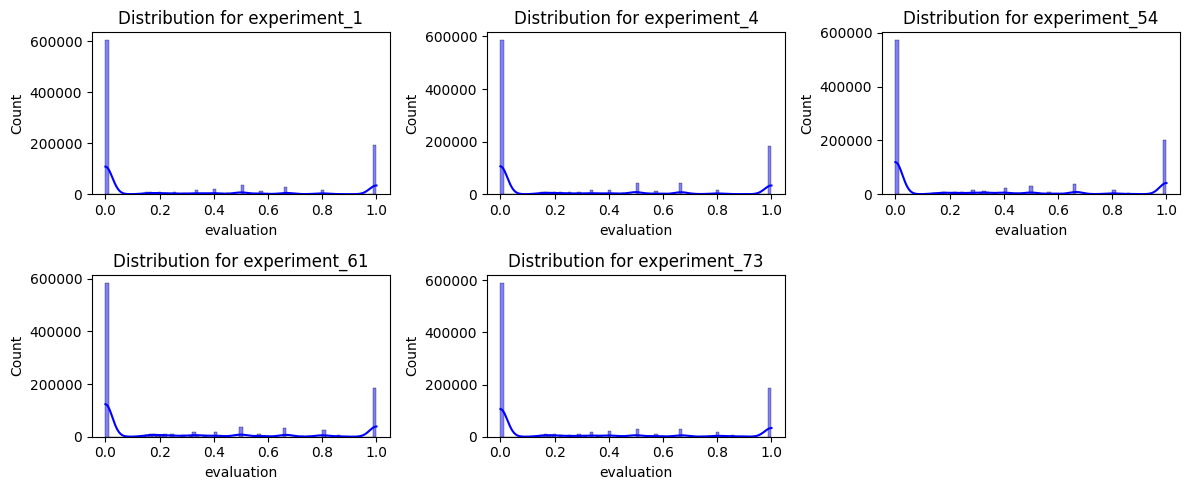

In [8]:
experiments = groundtruth_train.select("experiment").unique().sort("experiment").to_series().to_list()
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()

for idx, exp in enumerate(experiments):
    exp_data = groundtruth_train.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("evaluation"), x="evaluation", color="blue", label=f"groundtruth - train - {exp}", kde=True, ax=axes[idx])
    axes[idx].set_title(f"Distribution for {exp}")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()


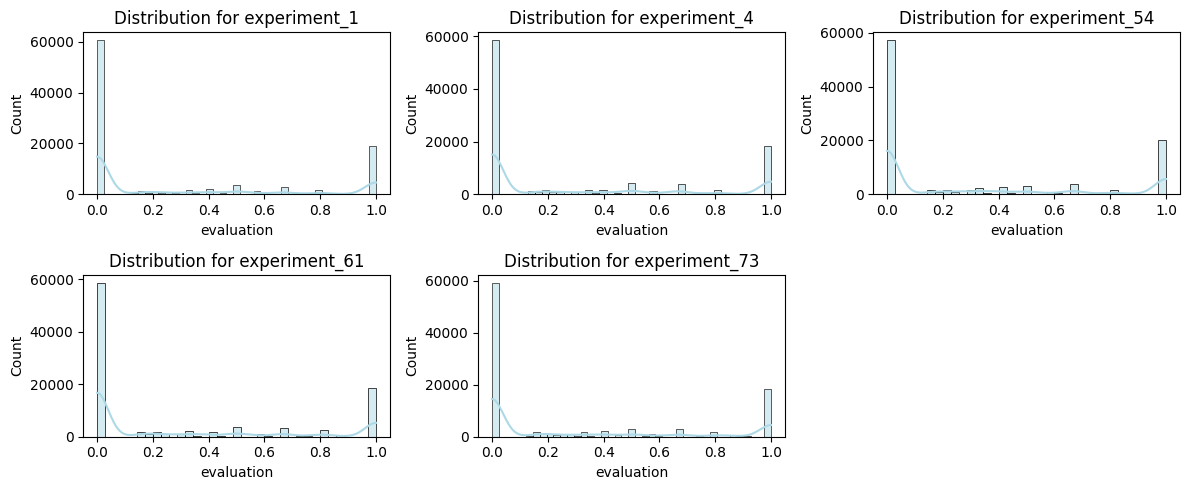

In [9]:
experiments = groundtruth_test.select("experiment").unique().sort("experiment").to_series().to_list()
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()

for idx, exp in enumerate(experiments):
    exp_data = groundtruth_test.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("evaluation"), x="evaluation", color="lightblue", label=f"groundtruth - test - {exp}", kde=True, ax=axes[idx])
    axes[idx].set_title(f"Distribution for {exp}")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()

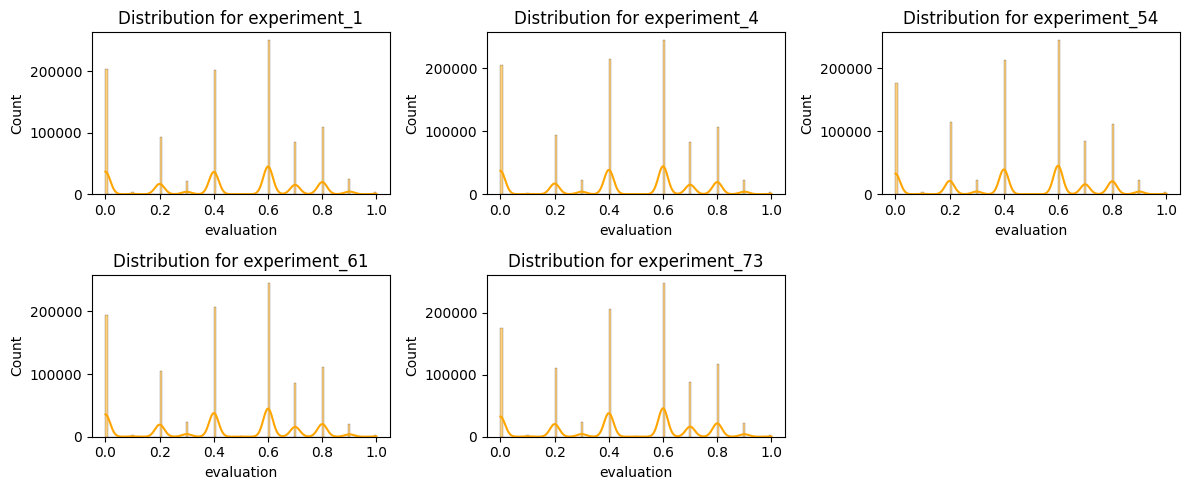

In [27]:
experiments = judge_train.select("experiment").unique().sort("experiment").to_series().to_list()
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()

for idx, exp in enumerate(experiments):
    exp_data = judge_train.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("evaluation"), x="evaluation", color="orange", label=f"judge - train - {exp}", kde=True, ax=axes[idx])
    axes[idx].set_title(f"Distribution for {exp}")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()

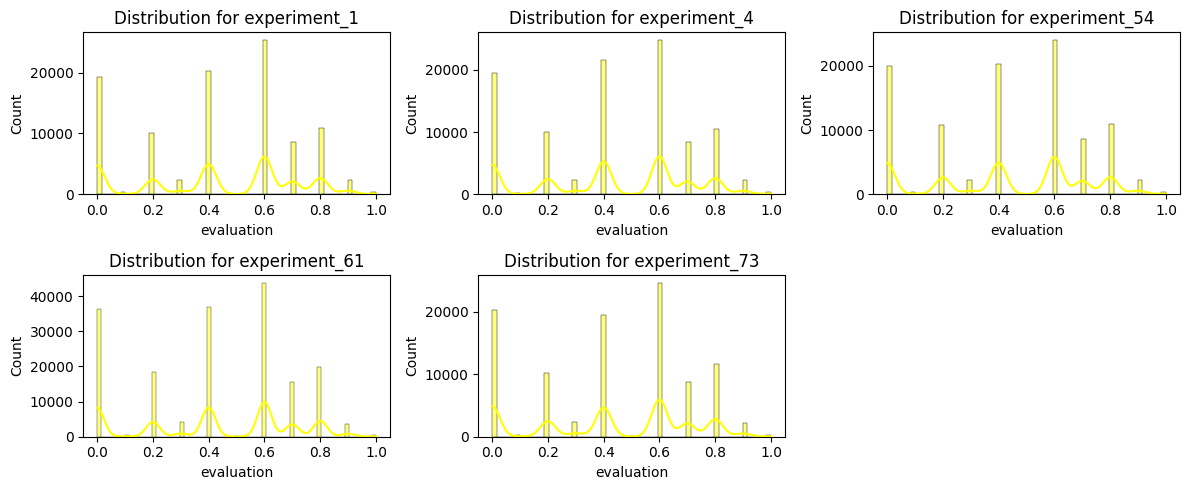

In [25]:
experiments = judge_test.select("experiment").unique().sort("experiment").to_series().to_list()
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()

for idx, exp in enumerate(experiments):
    exp_data = judge_test.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("evaluation"), x="evaluation", color="yellow", label=f"judge - test - {exp}", kde=True, ax=axes[idx])
    axes[idx].set_title(f"Distribution for {exp}")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()

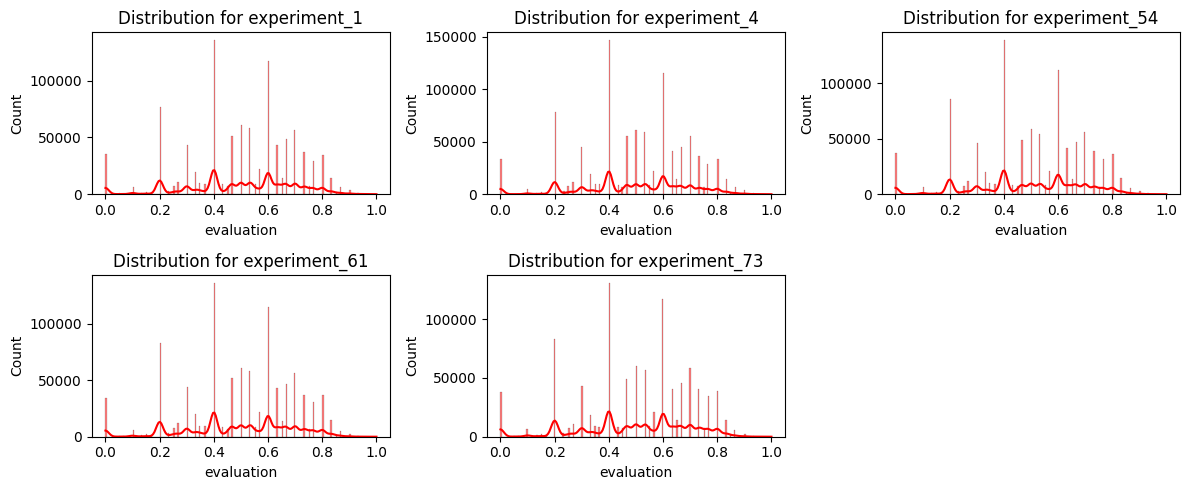

In [5]:
experiments = multi_train.select("experiment").unique().sort("experiment").to_series().to_list()
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()

for idx, exp in enumerate(experiments):
    exp_data = multi_train.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("evaluation"), x="evaluation", color="red", label=f"multi - train - {exp}", kde=True, ax=axes[idx])
    axes[idx].set_title(f"Distribution for {exp}")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()

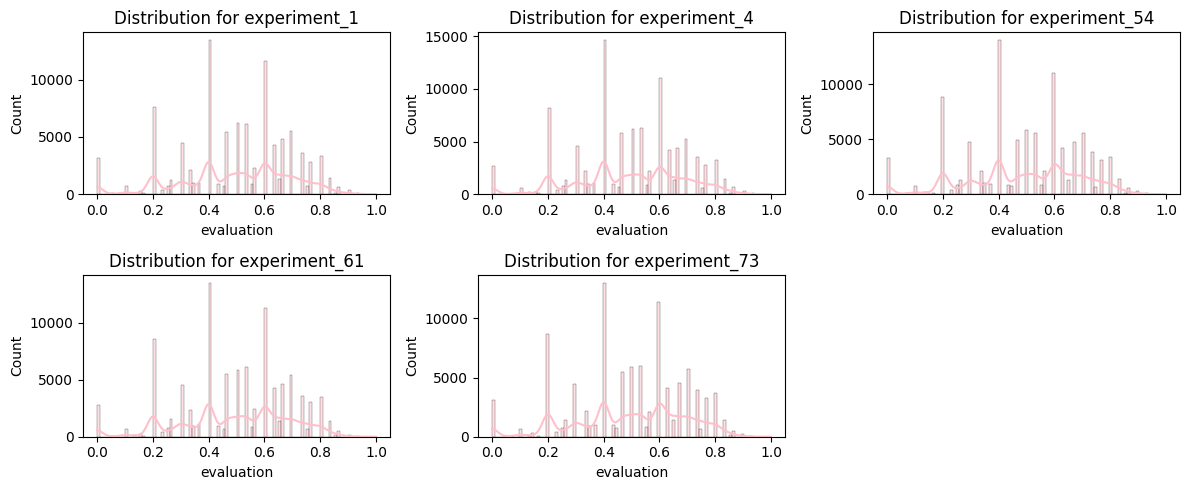

In [5]:
experiments = multi_test.select("experiment").unique().sort("experiment").to_series().to_list()
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()

for idx, exp in enumerate(experiments):
    exp_data = multi_test.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("evaluation"), x="evaluation", color="pink", label=f"multi - test - {exp}", kde=True, ax=axes[idx])
    axes[idx].set_title(f"Distribution for {exp}")

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()

In [31]:
### % overlap of zeros between judge train and groundtruth train
zeros_jtrain = judge_train.filter(pl.col("evaluation") == 0).select("collection_idx", "test_idx", "experiment")
zeros_gtrain = groundtruth_train.filter(pl.col("evaluation") == 0).select("collection_idx", "test_idx", "experiment")
zeros_jtrain.group_by("experiment").agg(pl.col("test_idx").count())

experiment,test_idx
str,u32
"""experiment_61""",194289
"""experiment_54""",176467
"""experiment_1""",204101
"""experiment_4""",204942
"""experiment_73""",175660


In [32]:
zeros_gtrain.group_by("experiment").agg(pl.col("test_idx").count())

experiment,test_idx
str,u32
"""experiment_4""",586280
"""experiment_54""",573442
"""experiment_61""",585820
"""experiment_73""",590978
"""experiment_1""",604027


In [34]:
from numpy import zeros


zeros_overlap = (
    zeros_jtrain.join(
        zeros_gtrain,
        on=["collection_idx", "test_idx", "experiment"],
        how="inner"
    ).group_by("experiment")
    .agg(pl.col("test_idx").count())
)
zeros_overlap

experiment,test_idx
str,u32
"""experiment_4""",146165
"""experiment_54""",127406
"""experiment_73""",128241
"""experiment_61""",139653
"""experiment_1""",151666


## Linear Regression


In [46]:
## Train linear regression
from sklearn.linear_model import LinearRegression

print("Loading training sets and training linear regression models...")
X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train, X_multi_train, y_multi_train = get_train_sets(df)
ground_truth_lr_models = {exp:[] for exp in EXPERIMENTS}
judge_lr_models = {exp:[] for exp in EXPERIMENTS}
multi_lr_models = {exp:[] for exp in EXPERIMENTS}
offset  = 2000
n = 500

for exp_idx in range(len(EXPERIMENTS)):
    for sample in range(n):
        _x = X_groundtruth_train[exp_idx][sample:offset*n:n]
        _y = y_groundtruth_train[exp_idx][sample:offset*n:n]
        groundtruth_lr = LinearRegression().fit(_x, _y)

        _x = X_judge_train[exp_idx][sample:offset*n:n]
        _y = y_judge_train[exp_idx][sample:offset*n:n]
        judge_lr = LinearRegression().fit(_x, _y)

        _x = X_multi_train[exp_idx][sample:offset*n:n]
        _y = y_multi_train[exp_idx][sample:offset*n:n]
        multi_lr = LinearRegression().fit(_x, _y)

        ground_truth_lr_models[EXPERIMENTS[exp_idx]].append(groundtruth_lr)
        judge_lr_models[EXPERIMENTS[exp_idx]].append(judge_lr)
        multi_lr_models[EXPERIMENTS[exp_idx]].append(multi_lr)


del X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train, X_multi_train, y_multi_train
gc.collect()

Loading training sets and training linear regression models...


61997

In [47]:
### saving weights as tensores
for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] for arr in ground_truth_lr_models[EXPERIMENTS[exp]]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] for arr in judge_lr_models[EXPERIMENTS[exp]]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in ground_truth_lr_models[EXPERIMENTS[exp]]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lr_bias.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in judge_lr_models[EXPERIMENTS[exp]]]), f"weights/judge/{EXPERIMENTS[exp]}/lr_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] for arr in multi_lr_models[EXPERIMENTS[exp]]]), f"weights/multi/{EXPERIMENTS[exp]}/lr_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in multi_lr_models[EXPERIMENTS[exp]]]), f"weights/multi/{EXPERIMENTS[exp]}/lr_bias.pt")

### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_judge/"
    gt_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_groundtruth/"
    mu_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lr_multi/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)
    os.makedirs(mu_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] for arr in ground_truth_lr_models[EXPERIMENTS[exp]]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] for arr in judge_lr_models[EXPERIMENTS[exp]]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in ground_truth_lr_models[EXPERIMENTS[exp]]]), f"{gt_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in judge_lr_models[EXPERIMENTS[exp]]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] for arr in multi_lr_models[EXPERIMENTS[exp]]]), f"{mu_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in multi_lr_models[EXPERIMENTS[exp]]]), f"{mu_path}/0_499_bias.pt")
    

In [4]:
X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test, X_multi_test, y_multi_test = get_test_sets(df)


In [8]:
X_groundtruth_test[2].shape

(100000, 100)

In [48]:
X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test, X_multi_test, y_multi_test = get_test_sets(df)


offset  = 200
n = 500
ground_truth_lr_evals = {exp:[] for exp in EXPERIMENTS}
judge_lr_evals = {exp:[] for exp in EXPERIMENTS}
multi_lr_evals = {exp:[] for exp in EXPERIMENTS}
ground_truth_mae = {exp:[] for exp in EXPERIMENTS}
judge_mae = {exp:[] for exp in EXPERIMENTS}
multi_mae = {exp:[] for exp in EXPERIMENTS}


for exp_idx in range(len(EXPERIMENTS)):
    
    for sample in range(n):
        lr = judge_lr_models[EXPERIMENTS[exp_idx]][sample]
        _x = X_judge_test[exp_idx][sample: n*offset: n]
        _y = y_judge_test[exp_idx][sample: n*offset: n]
        score = lr.score(_x, _y)
        y_pred = lr.predict(_x)
        mae = mean_absolute_error(_y, y_pred)
        judge_lr_evals[EXPERIMENTS[exp_idx]].append(score)
        judge_mae[EXPERIMENTS[exp_idx]].append(mae)

        lr = ground_truth_lr_models[EXPERIMENTS[exp_idx]][sample]
        _x = X_groundtruth_test[exp_idx][sample: n*offset: n]
        _y = y_groundtruth_test[exp_idx][sample: n*offset: n]
        score = lr.score(_x, _y)
        y_pred = lr.predict(_x)
        mae = mean_absolute_error(_y, y_pred)
        ground_truth_mae[EXPERIMENTS[exp_idx]].append(mae)
        
        ground_truth_lr_evals[EXPERIMENTS[exp_idx]].append(score)

        lr = multi_lr_models[EXPERIMENTS[exp_idx]][sample]
        _x = X_multi_test[exp_idx][sample: n*offset: n]
        _y = y_multi_test[exp_idx][sample: n*offset: n]
        score = lr.score(_x, _y)
        y_pred = lr.predict(_x)
        mae = mean_absolute_error(_y, y_pred)
        multi_mae[EXPERIMENTS[exp_idx]].append(mae)
        multi_lr_evals[EXPERIMENTS[exp_idx]].append(score)


del X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test, X_multi_test, y_multi_test
gc.collect()

0

In [49]:
df_evals = pl.DataFrame(
        {
            "idx": [i for i in range(n)] * 5,
            "experiment": [exp for exp in EXPERIMENTS for i in range(n)],
            "judge_lr_score": [judge_lr_evals[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "groundtruth_lr_score": [ground_truth_lr_evals[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "multi_lr_score": [multi_lr_evals[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "judge_mae": [judge_mae[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "groundtruth_mae": [ground_truth_mae[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "multi_mae": [multi_mae[exp][i] for exp in EXPERIMENTS for i in range(n)],
            }

)

df_evals.head()


idx,experiment,judge_lr_score,groundtruth_lr_score,multi_lr_score,judge_mae,groundtruth_mae,multi_mae
i64,str,f64,f64,f64,f64,f64,f64
0,"""experiment_1""",-0.117579,-0.357772,-0.078663,0.155441,0.47542,0.098791
1,"""experiment_1""",-0.038624,-0.172347,-0.122685,0.249858,0.255923,0.144152
2,"""experiment_1""",-0.050718,-0.386231,-0.201233,0.149563,0.343043,0.086505
3,"""experiment_1""",-0.056658,-0.284716,-0.138015,0.159248,0.436783,0.118407
4,"""experiment_1""",-0.265316,-0.681677,-0.406749,0.251844,0.445668,0.203594


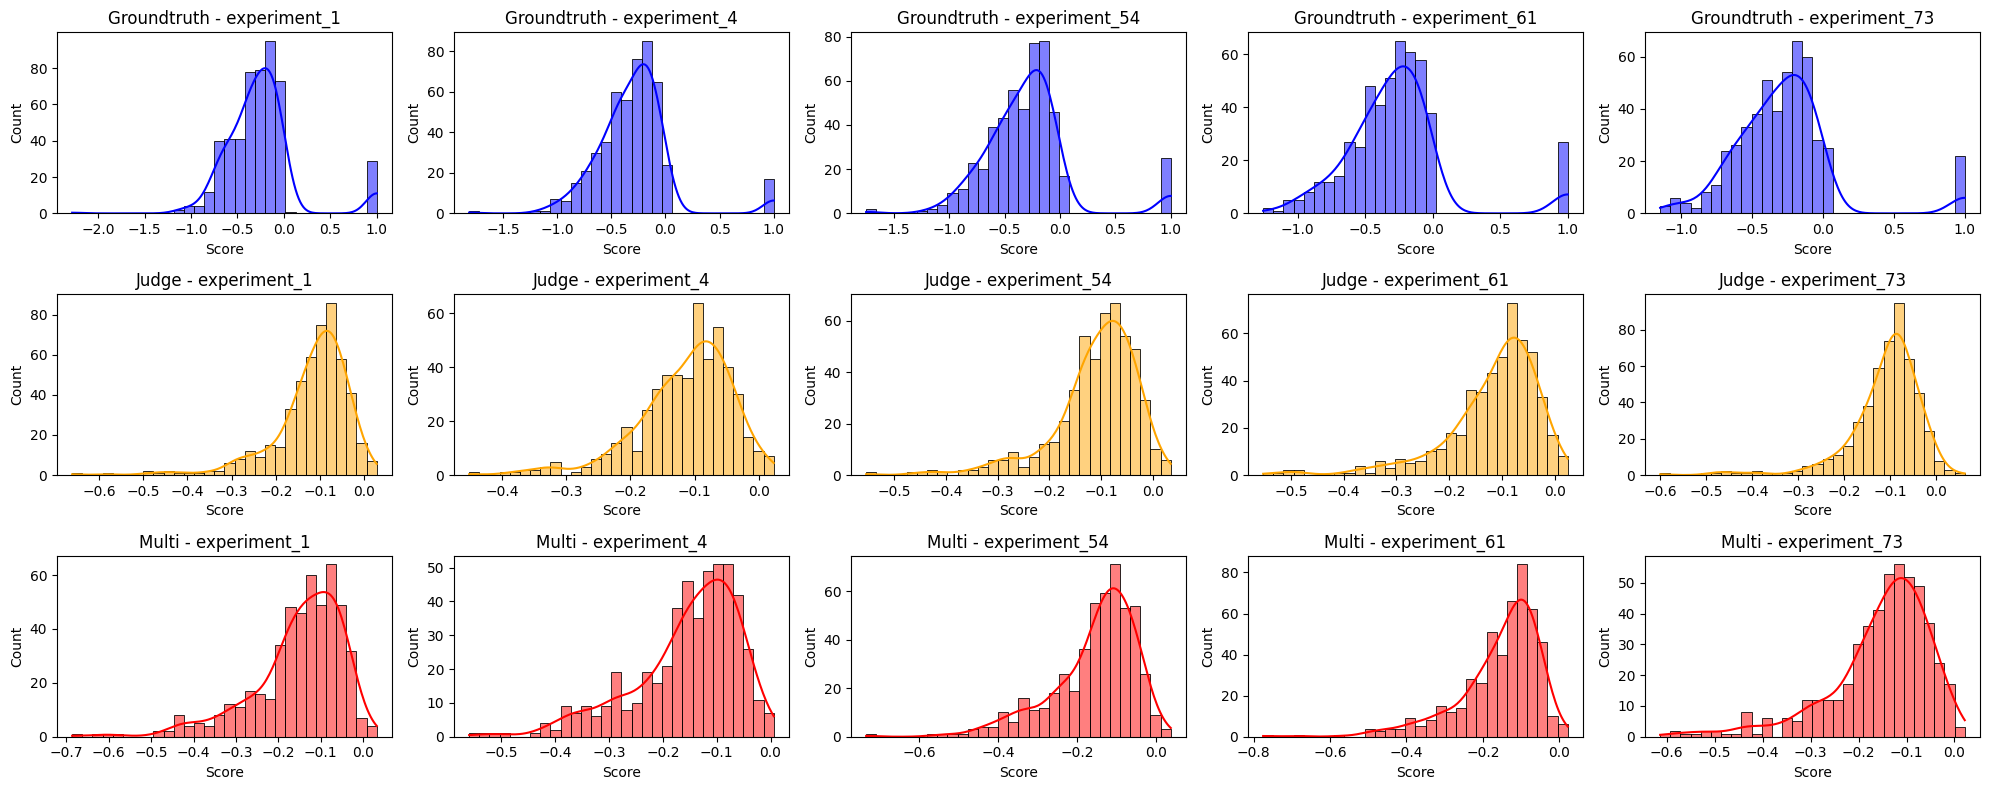

In [50]:
### Barplot hist of evals by experiment and type of score (grid 2,5)
fig, axes = plt.subplots(3, 5, figsize=(20, 8))

# First row: groundtruth scores (blue)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = df_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("groundtruth_lr_score").to_pandas(), x="groundtruth_lr_score", color="blue", kde=True, ax=axes[0, idx], bins=30)
    axes[0, idx].set_title(f"Groundtruth - {exp}", fontsize=12)
    axes[0, idx].set_xlabel("Score")

# Second row: judge scores (orange)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = df_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("judge_lr_score").to_pandas(), x="judge_lr_score", color="orange", kde=True, ax=axes[1, idx], bins=30)
    axes[1, idx].set_title(f"Judge - {exp}", fontsize=12)
    axes[1, idx].set_xlabel("Score")

for idx, exp in enumerate(EXPERIMENTS):
    exp_data = df_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("multi_lr_score").to_pandas(), x="multi_lr_score", color="red", kde=True, ax=axes[2, idx], bins=30)
    axes[2, idx].set_title(f"Multi - {exp}", fontsize=12)
    axes[2, idx].set_xlabel("Score")

plt.tight_layout()
plt.show()

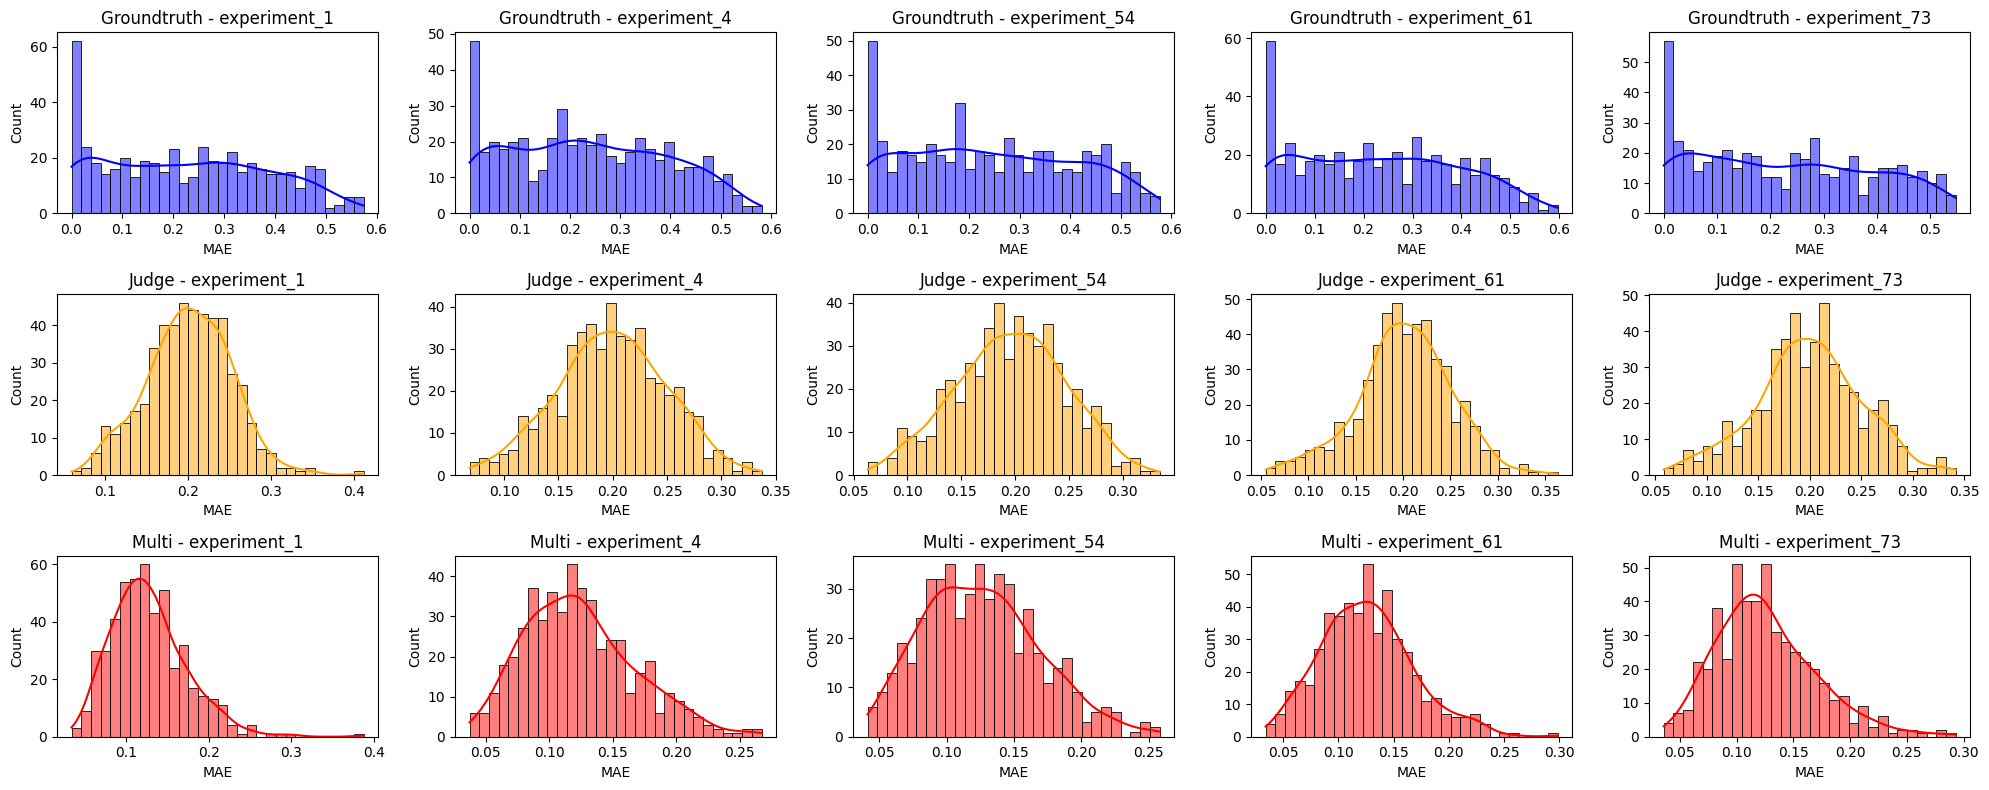

In [51]:
### Barplot hist of evals by experiment and type of score (grid 3,5)
fig, axes = plt.subplots(3, 5, figsize=(20, 8))

# First row: groundtruth scores (blue)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = df_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("groundtruth_mae").to_pandas(), x="groundtruth_mae", color="blue", kde=True, ax=axes[0, idx], bins=30)
    axes[0, idx].set_title(f"Groundtruth - {exp}", fontsize=12)
    axes[0, idx].set_xlabel("MAE")

# Second row: judge scores (orange)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = df_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("judge_mae").to_pandas(), x="judge_mae", color="orange", kde=True, ax=axes[1, idx], bins=30)
    axes[1, idx].set_title(f"Judge - {exp}", fontsize=12)
    axes[1, idx].set_xlabel("MAE")

for idx, exp in enumerate(EXPERIMENTS):
    exp_data = df_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("multi_mae").to_pandas(), x="multi_mae", color="red", kde=True, ax=axes[2, idx], bins=30)
    axes[2, idx].set_title(f"Multi - {exp}", fontsize=12)
    axes[2, idx].set_xlabel("MAE")

plt.tight_layout()
plt.show()

## Linear Regression - Text Generation Results

In [6]:
from utils.metrics.calculate_metric import calculate_agg_metric


wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            print(f"Processing {file} for experiment {exp}...")
            dfs_generations.append(calculate_agg_metric(
                metrics=["rouge_l"],
                generation_path=f"runs/{exp}/generations/{file}",
                reference_path=questions_path    ,
                saving_path=None            
            )
            .with_columns([
                pl.lit(exp).alias("experiment"),
                pl.lit(file.split('_')[1].split('.')[0]).alias("model"),
            ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/generation_results.feather")
else:
    generations_results = pl.read_ipc("generation_results/generation_results.feather")        

Processing lr_judge.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--rouge/b01e0accf3bd6dd24839b769a5fda24e14995071570870922c71970b3a6ed886 (last modified on Wed Oct 16 22:50:24 2024) since it couldn't be found locally at evaluate-metric--rouge, or remotely on the Hugging Face Hub.


Processing lr_multi.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_groundtruth.json for experiment experiment_1...


...

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_judge.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lr_groundtruth.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


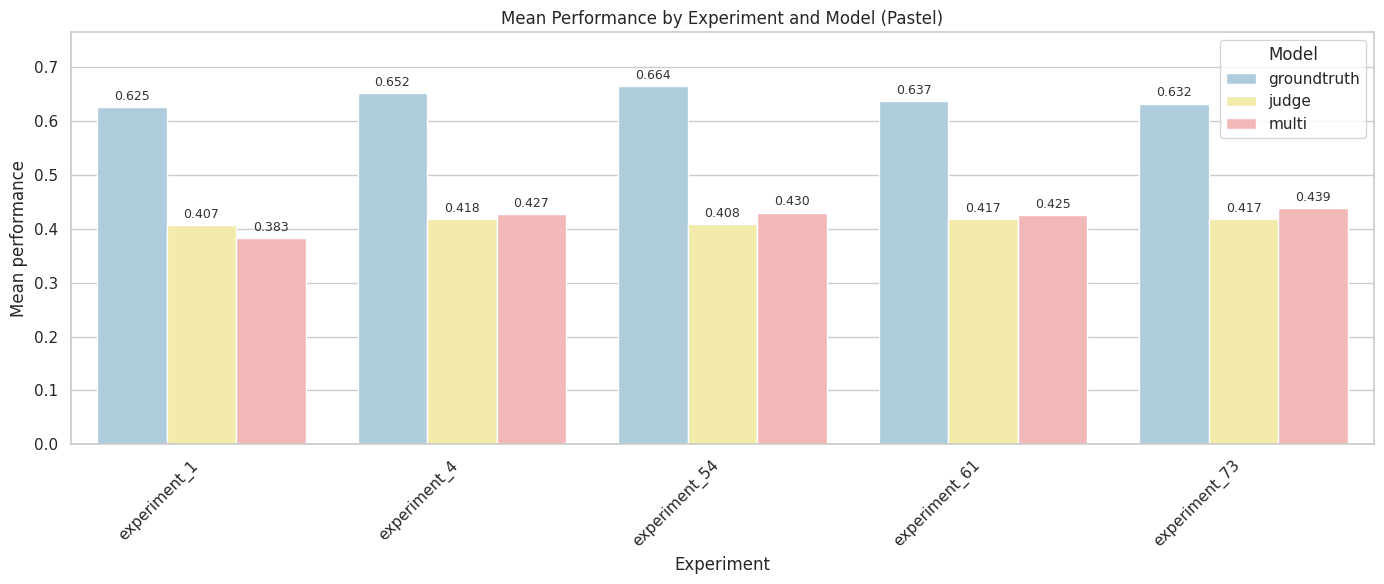

In [9]:
# Barplot: mean performance by experiment and model (pastel + labels)
# Uses Polars `_df` and colors: groundtruth=blue, judge=yellow, multi=red

# Ensure the aggregated column is named `mean`
_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["groundtruth", "judge", "multi"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "groundtruth": "#a6cee3",  # pastel blue
    "judge": "#fff59d",        # pastel yellow
    "multi": "#fcaeae",        # pastel red/pink
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

##  Lasso - Training and Evaluation

In [4]:
## LASSO CV IMPLEMENTATION
from sklearn.linear_model import LassoCV
from tqdm import tqdm

X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train, X_multi_train, y_multi_train = get_train_sets(df)
groundtruth_lasso = {exp:[] for exp in EXPERIMENTS}
judge_lasso = {exp:[] for exp in EXPERIMENTS}
multi_lasso = {exp:[] for exp in EXPERIMENTS}


offset  = 2000
n = 500
total_iterations = len(EXPERIMENTS) * n

with tqdm(total=total_iterations, desc="Training Lasso Models") as pbar:
    for exp_idx in range(len(EXPERIMENTS)):
        for sample in range(n):
            _x = X_groundtruth_train[exp_idx][sample:offset*n:n]
            _y = y_groundtruth_train[exp_idx][sample:offset*n:n].ravel()
            groundtruth_model = LassoCV(cv=3, random_state=42, alphas=100).fit(_x, _y)
            

            _x = X_judge_train[exp_idx][sample:offset*n:n]
            _y = y_judge_train[exp_idx][sample:offset*n:n].ravel()
            judge_model = LassoCV(cv=3, random_state=42, alphas=100).fit(_x, _y)

            _x = X_multi_train[exp_idx][sample:offset*n:n]
            _y = y_multi_train[exp_idx][sample:offset*n:n].ravel()
            multi_model = LassoCV(cv=3, random_state=42, alphas=100).fit(_x, _y)


            groundtruth_lasso[EXPERIMENTS[exp_idx]].append(groundtruth_model)
            judge_lasso[EXPERIMENTS[exp_idx]].append(judge_model)
            multi_lasso[EXPERIMENTS[exp_idx]].append(multi_model)
            
            pbar.update(1)


del X_groundtruth_train, y_groundtruth_train, X_judge_train, y_judge_train, X_multi_train, y_multi_train
gc.collect()


Training Lasso Models: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [10:16<00:00,  4.06it/s]


1604

In [10]:
judge_lasso["experiment_1"][0].coef_

array([ 0.        , -0.00115532,  0.04916493, -0.        ,  0.        ,
       -0.        , -0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        , -0.00795252, -0.0011242 ,
        0.        , -0.        ,  0.00064977, -0.        , -0.02172611,
       -0.        ,  0.        , -0.        ,  0.00608648,  0.        ,
        0.        , -0.        , -0.        ,  0.        , -0.        ,
       -0.        , -0.        ,  0.        , -0.        ,  0.00321857,
        0.        ,  0.01240667,  0.        ,  0.        ,  0.        ,
        0.        , -0.        , -0.        ,  0.        , -0.        ,
       -0.        ,  0.        ,  0.        ,  0.01105439, -0.        ,
       -0.        , -0.        , -0.02601743,  0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        ,  0.        ,  0.        , -0.01359054,
        0.        ,  0.        ,  0.00022129, -0.        , -0.  

In [12]:
### saving weights as tensores
for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_ for arr in groundtruth_lasso[EXPERIMENTS[exp]]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lasso_weights.pt")
    torch.save(torch.tensor([arr.coef_ for arr in judge_lasso[EXPERIMENTS[exp]]]), f"weights/judge/{EXPERIMENTS[exp]}/lasso_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in groundtruth_lasso[EXPERIMENTS[exp]]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/lasso_bias.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in judge_lasso[EXPERIMENTS[exp]]]), f"weights/judge/{EXPERIMENTS[exp]}/lasso_bias.pt")
    torch.save(torch.tensor([arr.coef_ for arr in multi_lasso[EXPERIMENTS[exp]]]), f"weights/multi/{EXPERIMENTS[exp]}/lasso_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in multi_lasso[EXPERIMENTS[exp]]]), f"weights/multi/{EXPERIMENTS[exp]}/lasso_bias.pt")

### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lasso_judge/"
    gt_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lasso_groundtruth/"
    mu_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/lasso_multi/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)
    os.makedirs(mu_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_ for arr in groundtruth_lasso[EXPERIMENTS[exp]]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_ for arr in judge_lasso[EXPERIMENTS[exp]]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in groundtruth_lasso[EXPERIMENTS[exp]]]), f"{gt_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in judge_lasso[EXPERIMENTS[exp]]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_ for arr in multi_lasso[EXPERIMENTS[exp]]]), f"{mu_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ for arr in multi_lasso[EXPERIMENTS[exp]]]), f"{mu_path}/0_499_bias.pt")
    

In [15]:
X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test, X_multi_test, y_multi_test = get_test_sets(df)


offset  = 200
n = 500
groundtruth_lasso_evals = {exp:[] for exp in EXPERIMENTS}
judge_lasso_evals = {exp:[] for exp in EXPERIMENTS}
multi_lasso_evals = {exp:[] for exp in EXPERIMENTS}
groundtruth_mae = {exp:[] for exp in EXPERIMENTS}
judge_mae = {exp:[] for exp in EXPERIMENTS}
multi_mae = {exp:[] for exp in EXPERIMENTS}


for exp_idx in range(len(EXPERIMENTS)):
    
    for sample in range(n):
        lr = judge_lasso[EXPERIMENTS[exp_idx]][sample]
        _x = X_judge_test[exp_idx][sample: n*offset: n]
        _y = y_judge_test[exp_idx][sample: n*offset: n]
        score = lr.score(_x, _y)
        y_pred = lr.predict(_x)
        mae = mean_absolute_error(_y, y_pred)
        judge_lasso_evals[EXPERIMENTS[exp_idx]].append(score)
        judge_mae[EXPERIMENTS[exp_idx]].append(mae)

        lr = groundtruth_lasso[EXPERIMENTS[exp_idx]][sample]
        _x = X_groundtruth_test[exp_idx][sample: n*offset: n]
        _y = y_groundtruth_test[exp_idx][sample: n*offset: n]
        score = lr.score(_x, _y)
        y_pred = lr.predict(_x)
        mae = mean_absolute_error(_y, y_pred)
        groundtruth_mae[EXPERIMENTS[exp_idx]].append(mae)
        
        groundtruth_lasso_evals[EXPERIMENTS[exp_idx]].append(score)

        lr = multi_lasso[EXPERIMENTS[exp_idx]][sample]
        _x = X_multi_test[exp_idx][sample: n*offset: n]
        _y = y_multi_test[exp_idx][sample: n*offset: n]
        score = lr.score(_x, _y)
        y_pred = lr.predict(_x)
        mae = mean_absolute_error(_y, y_pred)
        multi_mae[EXPERIMENTS[exp_idx]].append(mae)
        multi_lasso_evals[EXPERIMENTS[exp_idx]].append(score)


del X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test, X_multi_test, y_multi_test
gc.collect()

582

In [16]:
lasso_evals = pl.DataFrame(
        {
            "idx": [i for i in range(n)] * 5,
            "experiment": [exp for exp in EXPERIMENTS for i in range(n)],
            "judge_lr_score": [judge_lasso_evals[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "groundtruth_lr_score": [groundtruth_lasso_evals[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "multi_lr_score": [multi_lasso_evals[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "judge_mae": [judge_mae[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "groundtruth_mae": [groundtruth_mae[exp][i] for exp in EXPERIMENTS for i in range(n)],
            "multi_mae": [multi_mae[exp][i] for exp in EXPERIMENTS for i in range(n)],
            }

)

lasso_evals.head()

idx,experiment,judge_lr_score,groundtruth_lr_score,multi_lr_score,judge_mae,groundtruth_mae,multi_mae
i64,str,f64,f64,f64,f64,f64,f64
0,"""experiment_1""",-0.019528,-0.297722,-0.00636,0.141581,0.468437,0.094295
1,"""experiment_1""",0.000599,-0.124177,-0.028888,0.248539,0.249462,0.13802
2,"""experiment_1""",-0.007923,-0.280294,-0.02996,0.150133,0.329797,0.079595
3,"""experiment_1""",0.005247,-0.215005,-0.04898,0.155244,0.427847,0.114153
4,"""experiment_1""",-0.191591,-0.580471,-0.324271,0.249509,0.436978,0.197596


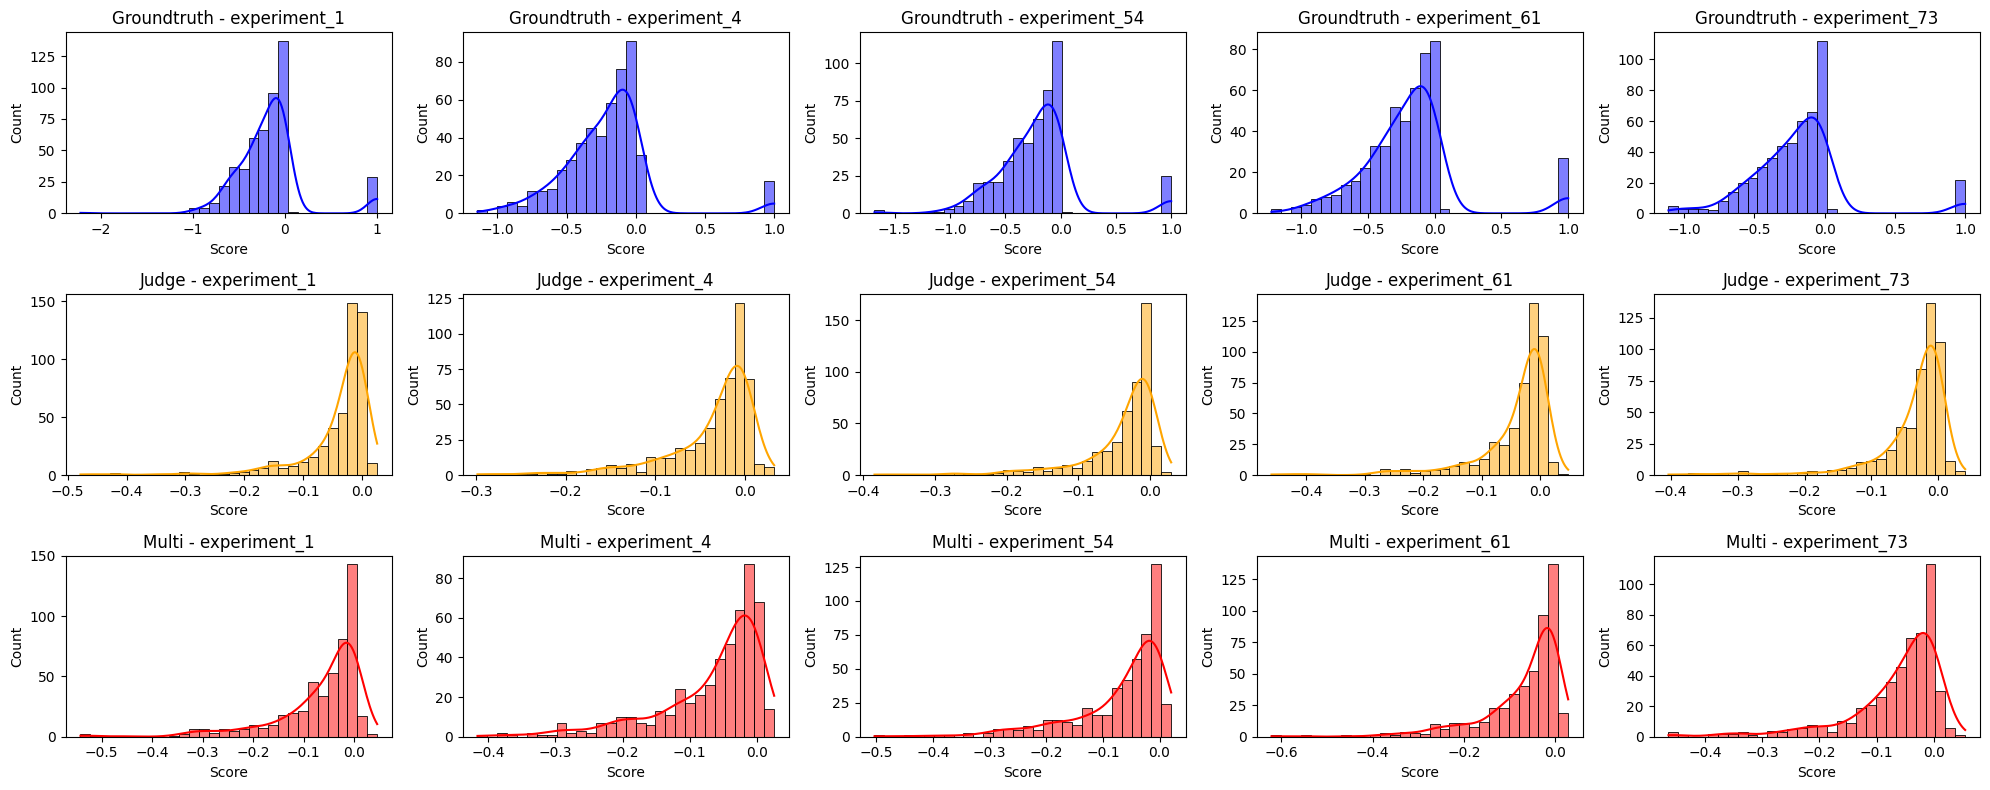

In [18]:
### Barplot hist of evals by experiment and type of score (grid 2,5)
fig, axes = plt.subplots(3, 5, figsize=(20, 8))

# First row: groundtruth scores (blue)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = lasso_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("groundtruth_lr_score").to_pandas(), x="groundtruth_lr_score", color="blue", kde=True, ax=axes[0, idx], bins=30)
    axes[0, idx].set_title(f"Groundtruth - {exp}", fontsize=12)
    axes[0, idx].set_xlabel("Score")

# Second row: judge scores (orange)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = lasso_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("judge_lr_score").to_pandas(), x="judge_lr_score", color="orange", kde=True, ax=axes[1, idx], bins=30)
    axes[1, idx].set_title(f"Judge - {exp}", fontsize=12)
    axes[1, idx].set_xlabel("Score")

for idx, exp in enumerate(EXPERIMENTS):
    exp_data = lasso_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("multi_lr_score").to_pandas(), x="multi_lr_score", color="red", kde=True, ax=axes[2, idx], bins=30)
    axes[2, idx].set_title(f"Multi - {exp}", fontsize=12)
    axes[2, idx].set_xlabel("Score")

plt.tight_layout()
plt.show()

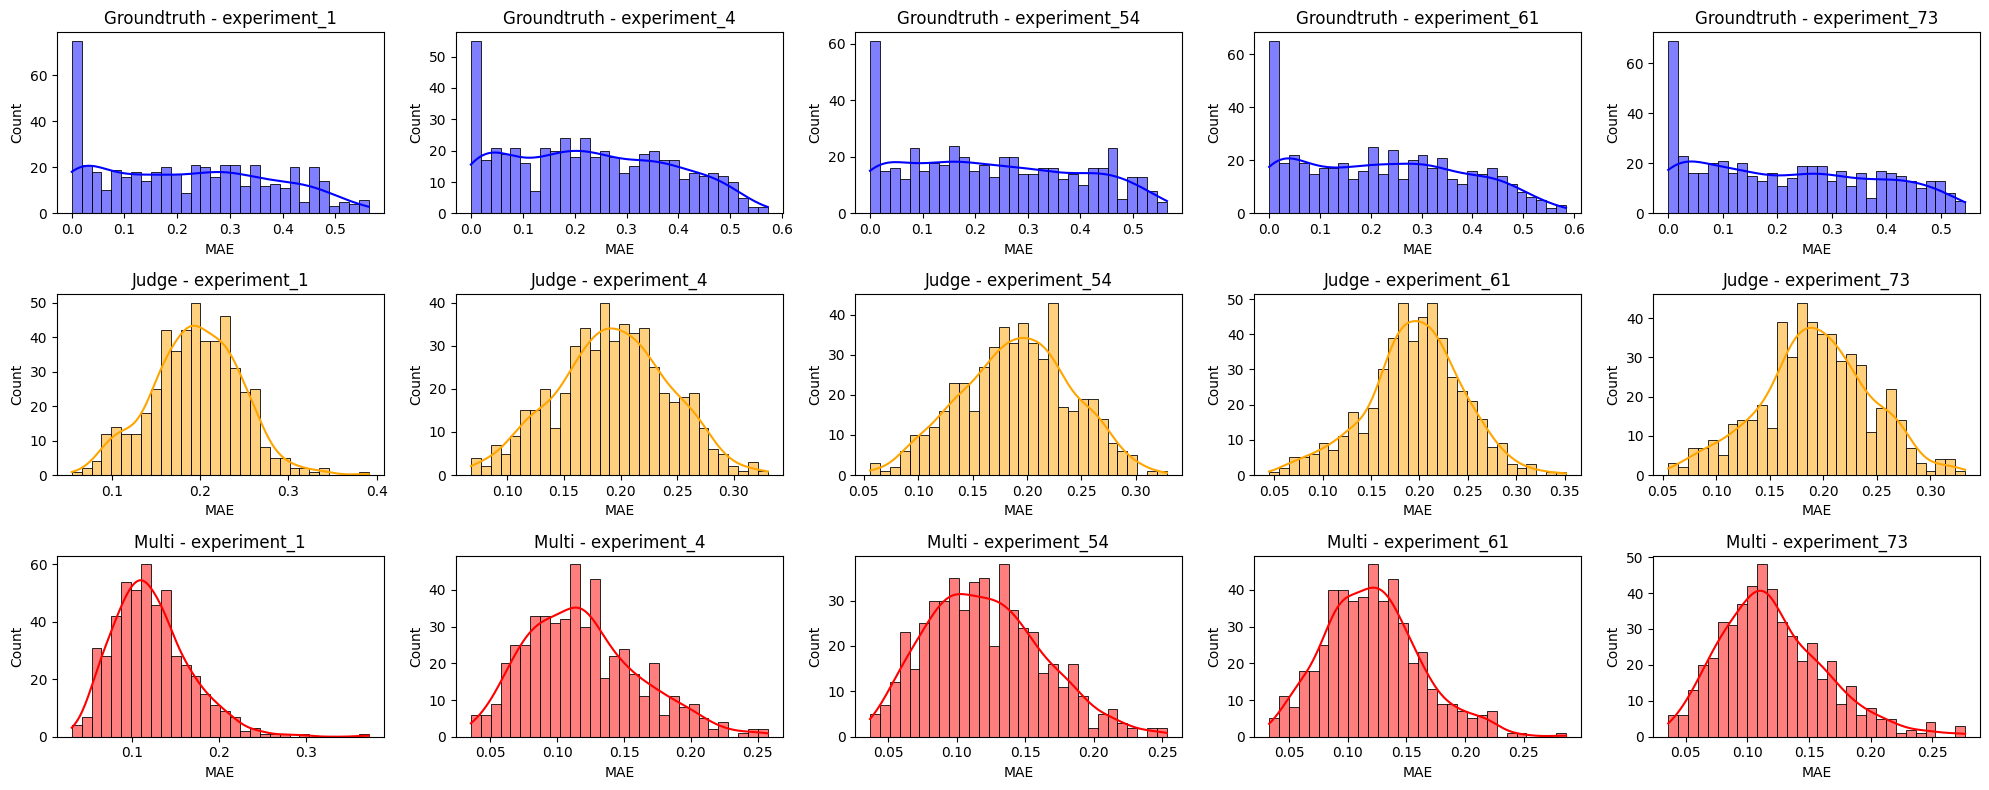

In [19]:
### Barplot hist of evals by experiment and type of score (grid 3,5)
fig, axes = plt.subplots(3, 5, figsize=(20, 8))

# First row: groundtruth scores (blue)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = lasso_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("groundtruth_mae").to_pandas(), x="groundtruth_mae", color="blue", kde=True, ax=axes[0, idx], bins=30)
    axes[0, idx].set_title(f"Groundtruth - {exp}", fontsize=12)
    axes[0, idx].set_xlabel("MAE")

# Second row: judge scores (orange)
for idx, exp in enumerate(EXPERIMENTS):
    exp_data = lasso_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("judge_mae").to_pandas(), x="judge_mae", color="orange", kde=True, ax=axes[1, idx], bins=30)
    axes[1, idx].set_title(f"Judge - {exp}", fontsize=12)
    axes[1, idx].set_xlabel("MAE")

for idx, exp in enumerate(EXPERIMENTS):
    exp_data = lasso_evals.filter(pl.col("experiment") == exp)
    sns.histplot(data=exp_data.select("multi_mae").to_pandas(), x="multi_mae", color="red", kde=True, ax=axes[2, idx], bins=30)
    axes[2, idx].set_title(f"Multi - {exp}", fontsize=12)
    axes[2, idx].set_xlabel("MAE")

plt.tight_layout()
plt.show()

In [ ]:
from utils.metrics.calculate_metric import calculate_agg_metric


wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS[:3]:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if "lasso" in file and "judge" not in file:
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{file}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('_')[1].split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/lasso.feather")
else:
    generations_results = pl.read_ipc("generation_results/lasso.feather")        

/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 01-28 16:26:23 [__init__.py:216] Automatically detected platform cuda.
Processing lasso_groundtruth.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--rouge/b01e0accf3bd6dd24839b769a5fda24e14995071570870922c71970b3a6ed886 (last modified on Wed Oct 16 22:50:24 2024) since it couldn't be found locally at evaluate-metric--rouge, or remotely on the Hugging Face Hub.


Processing lasso_multi.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


...

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lasso_groundtruth.json for experiment experiment_54...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing lasso_multi.json for experiment experiment_54...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
